In [27]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import zscore

sns.set_theme(
    style="whitegrid",
    context="talk"
)

DATA_DIR = Path("../data/processed")
CHART_DIR = Path("../reports/charts")

CHART_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [28]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/processed")

fund_master = pd.read_csv(DATA_DIR/"01_fund_master_clean.csv")
nav = pd.read_csv(DATA_DIR/"02_nav_history_clean.csv")
aum = pd.read_csv(DATA_DIR/"03_aum_by_fund_house_clean.csv")
sip = pd.read_csv(DATA_DIR/"04_monthly_sip_inflows_clean.csv")
category = pd.read_csv(DATA_DIR/"05_category_inflows_clean.csv")
folio = pd.read_csv(DATA_DIR/"06_industry_folio_count_clean.csv")
performance = pd.read_csv(DATA_DIR/"07_scheme_performance_clean.csv")
investors = pd.read_csv(DATA_DIR/"08_investor_transactions_clean.csv")
holdings = pd.read_csv(DATA_DIR/"09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv(DATA_DIR/"10_benchmark_indices_clean.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [29]:
# Section 1 — Load ALL Cleaned Data

# This immediately aligns Day 3 with Day 2.
datasets = {
    "fund_master":
        pd.read_csv(DATA_DIR/"01_fund_master_clean.csv"),

    "nav":
        pd.read_csv(DATA_DIR/"02_nav_history_clean.csv"),

    "aum":
        pd.read_csv(DATA_DIR/"03_aum_by_fund_house_clean.csv"),

    "sip":
        pd.read_csv(DATA_DIR/"04_monthly_sip_inflows_clean.csv"),

    "category":
        pd.read_csv(DATA_DIR/"05_category_inflows_clean.csv"),

    "folio":
        pd.read_csv(DATA_DIR/"06_industry_folio_count_clean.csv"),

    "performance":
        pd.read_csv(DATA_DIR/"07_scheme_performance_clean.csv"),

    "investors":
        pd.read_csv(DATA_DIR/"08_investor_transactions_clean.csv"),

    "holdings":
        pd.read_csv(DATA_DIR/"09_portfolio_holdings_clean.csv"),

    "benchmark":
        pd.read_csv(DATA_DIR/"10_benchmark_indices_clean.csv")
}

In [30]:
# Section 2 — NAV Analytics (Advanced)

# Not NAV.

# NAV Returns
nav = datasets["nav"]

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
       
)
#Rolling Volatility
nav["rolling_volatility"] = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .transform(
           lambda x:
           x.rolling(30).std()
       )
)
#Top Performing Funds
fund_performance = (
    nav.groupby("amfi_code")
       .agg(
           first_nav=("nav","first"),
           last_nav=("nav","last")
       )
)

fund_performance["return_pct"] = (
    (
        fund_performance["last_nav"]
        -
        fund_performance["first_nav"]
    )
    /
    fund_performance["first_nav"]
    * 100
)

fund_performance.sort_values(
    "return_pct",
    ascending=False
).head(10)

,first_nav,last_nav,return_pct
amfi_code,,,
120505,135.8720,473.7640,248.684056
119598,89.8738,309.2050,244.043537
149324,81.6814,279.7511,242.490579
148569,28.8620,97.7435,238.658097
148567,70.2514,230.2708,227.781083
120843,49.9131,163.2397,227.047809
100033,107.3758,342.0072,218.514228
149323,78.4622,245.3651,212.717589
119094,68.3023,203.8581,198.464473


In [31]:
# Section 3 — AUM Market Concentration

# Most interns stop at bar charts.

# Calculate market share.
aum = datasets["aum"]

latest = (
    aum.sort_values("date")
       .groupby("fund_house")
       .tail(1)
)
#Market Share
latest["market_share_pct"] = (
    latest["aum_crore"]
    /
    latest["aum_crore"].sum()
    * 100
)
#HHI (Professional Metric)

#Used by regulators.
hhi = (
    latest["market_share_pct"]**2
).sum()

print(
    f"Industry HHI: {hhi:.0f}"
)

Industry HHI: 1282


In [32]:
# Section 4 — SIP Growth Analytics

# Not just trend.

# CAGR
sip = datasets["sip"]

start = sip.iloc[0]["sip_inflow_crore"]
end = sip.iloc[-1]["sip_inflow_crore"]

years = 4

cagr = (
    (end/start)**(1/years)
    -1
) * 100
#Record High Detection
peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]


(144, 3)


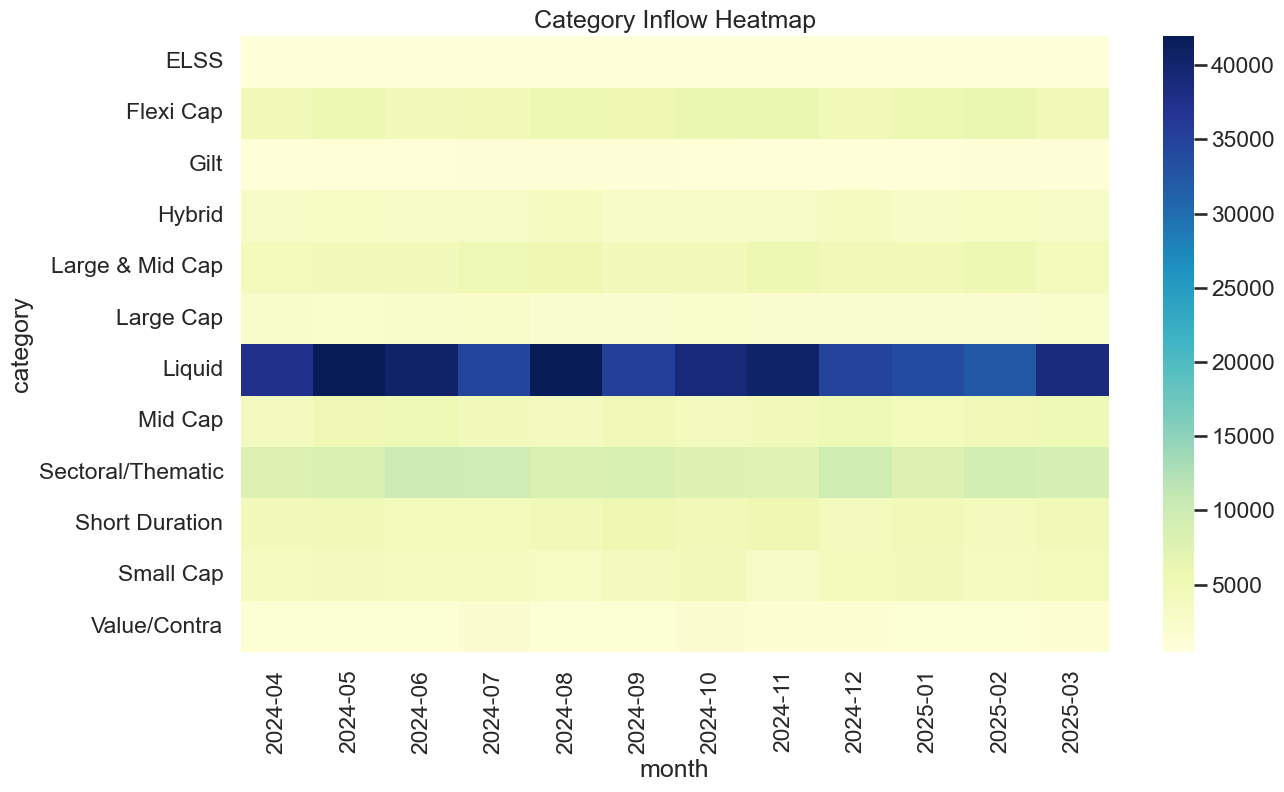

In [33]:
# Section 5 — Category Leadership

# Instead of heatmap only.

# Calculate:
category = datasets["category"]

print(category.shape)
category.head()
category_pivot = (
    category.pivot_table(
        index="category",
        columns="month",
        values="net_inflow_crore",
        aggfunc="sum"
    )
)

plt.figure(figsize=(14,8))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    annot=False
)

plt.title(
    "Category Inflow Heatmap"
)

plt.show()
category_pivot = (
    category.pivot_table(
        index="category",
        columns="month",
        values="net_inflow_crore",
        aggfunc="sum"
    )
)


In [34]:
# Section 6 — Investor Segmentation
# Age × Transaction Amount
age_summary = (
    investors
    .groupby("age_group")
    .agg(
        investors=("investor_id","count"),
        avg_amount=("amount_inr","mean"),
        median_amount=("amount_inr","median")
    )
)
#Gender Analysis
gender_summary = (
    investors
    .groupby("gender")
    ["amount_inr"]
    .agg(
        ["count","mean","sum"]
    )
)

In [35]:
# Section 7 — Geographic Penetration
# Top States
state = (
    investors.groupby("state")
             ["amount_inr"]
             .sum()
             .sort_values(
                 ascending=False
             )
)
# Concentration
top5_share = (
    state.head(5).sum()
    /
    state.sum()
    *100
)

In [36]:
# Section 8 — Folio Growth

# Instead of line chart.

# Calculate:

folio_growth = (
    (
        folio["total_folios_crore"].iloc[-1]
        -
        folio["total_folios_crore"].iloc[0]
    )
    /
    folio["total_folios_crore"].iloc[0]
    *100
)

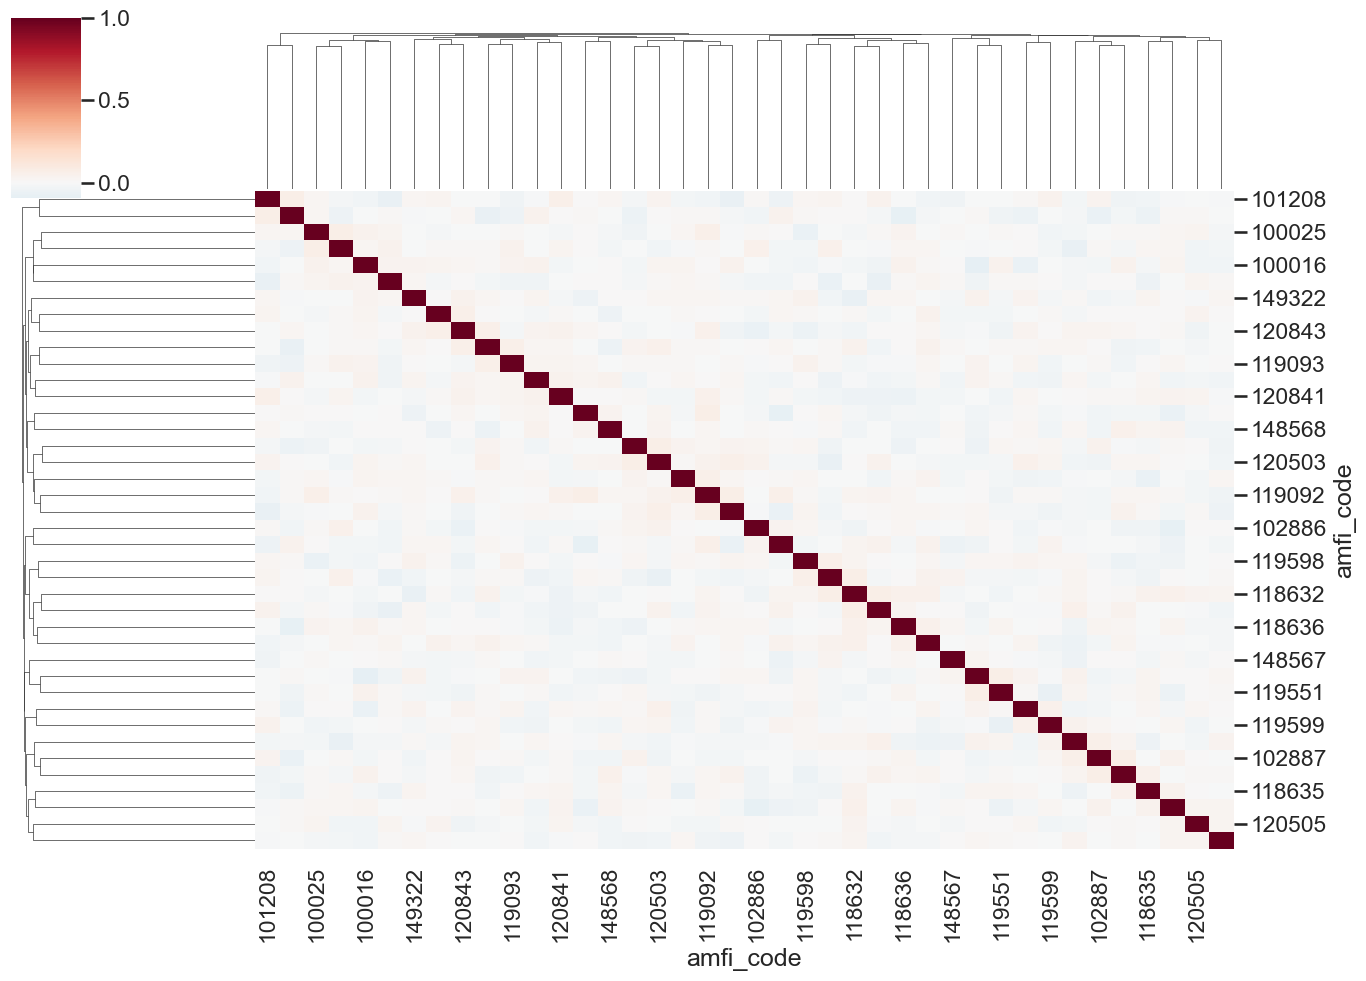

In [37]:
# Section 9 — Correlation Matrix

# This is where analysts get interested.

returns_matrix = (
    nav.pivot(
        index="date",
        columns="amfi_code",
        values="daily_return"
    )
)
# Clustered Correlation
sns.clustermap(
    returns_matrix.corr(),
    cmap="RdBu_r",
    center=0,
    figsize=(14,10)
)

In [38]:
# Section 10 — Sector Concentration Risk

# Your holdings dataset is surprisingly useful.

# Sector Weights
sector = (
    holdings.groupby("sector")
            ["weight_pct"]
            .sum()
            .sort_values(
                ascending=False
            )
)
# Concentration Ratio
top3 = (
    sector.head(3).sum()
)

In [39]:
print(aum.shape)
print(sip.shape)
print(category.shape)
print(folio.shape)
print(investors.shape)
print(holdings.shape)

(90, 5)
(48, 6)
(144, 3)
(21, 6)
(32778, 14)
(322, 8)


In [40]:
missing = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Missing Values": [df.isna().sum().sum() for df in datasets.values()]
})

missing

,Dataset,Rows,Columns,Missing Values
0,fund_master,40,15,0
1,nav,46000,3,0
2,aum,90,5,0
3,sip,48,6,12
4,category,144,3,0
5,folio,21,6,0
6,performance,40,20,0
7,investors,32778,14,0
8,holdings,322,8,0
9,benchmark,8050,3,0
